In [1]:
import kwant
from matplotlib import pyplot as plt
from scipy.constants import physical_constants
import numpy as np
from math import atan2, pi, sqrt
import ipywidgets as widgets

In [2]:
m_el = physical_constants['electron mass'][0]
m_eff = 0.067
eV = physical_constants['electron volt'][0]
hbar = physical_constants['Planck constant over 2 pi'][0]
e_diel = 13.9

In [3]:
a = 10 * 1e-9 # in nm
t = hbar**2 / (2 * m_el * m_eff * a**2) / eV
print(t)

0.005686540281567095


In [4]:
W = 40
L = 60

In [5]:
def rectangular_gate2(distance, left, right, bottom, top):

    d, l, r, b, t = distance, left, right, bottom, top

    def g(u, v):
        return atan2(u * v, d * sqrt(u**2 + v**2 + d**2)) / (2 * pi)

    def pot_func(x, y, U):
        return -U * (g(x-l, y-b) + g(x-l, t-y) + g(r-x, y-b) + g(r-x, t-y))/e_diel

    return pot_func
# Functions which simmulate potentials coming from electrods
def gate_top(x,y,v):
        f =rectangular_gate2(d,left, right, bottom2,top2)
        return f(x,y,v)
def gate_bottom(x,y,v):
        f =rectangular_gate2(d,left, right, bottom1,top1)
        return f(x,y,v)

In [6]:
d = 6 * a
left = 20 * a
right = 40 * a
bottom2 = 30 * a
top2 = 70 * a
bottom1 = -30 * a
top1 =10 * a

In [7]:
# We create system/build
sys = kwant.Builder()
latt = kwant.lattice.square(a, norbs = 1)

In [8]:
# We create potential/gaussian
def potential(x, y, U):
    return gate_top(x, y, U) + gate_bottom(x, y, U)

In [9]:
def onsite(site, U):
    x, y = site.pos
    return 4 * t + potential(x, y, U)

In [10]:
sys[(latt(x, y) for x in range(0, L) for y in range(0, W))] = onsite

In [11]:
sys[[latt.neighbors()]] = -t

In [12]:
# We add leads on the sides
leadl = kwant.Builder(kwant.TranslationalSymmetry((-a, 0)))
leadr = kwant.Builder(kwant.TranslationalSymmetry((a, 0)))

In [13]:
leadl[(latt(0, y) for y in range(0, W))] = onsite
leadr[(latt(0, y) for y in range(0, W))] = onsite

In [14]:
leadl[latt.neighbors()] = -t
leadr[latt.neighbors()] = -t

In [15]:
sys.attach_lead(leadl)
sys.attach_lead(leadr)

[]

In [16]:
sysf = sys.finalized()

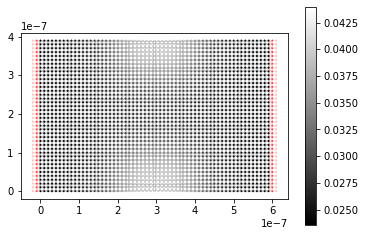

In [17]:
kwant.plot(sysf, site_color = lambda site : sysf.hamiltonian(site, site, params = dict(U = -0.5)));

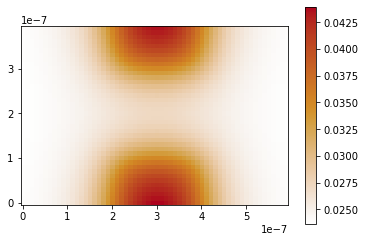

In [18]:
kwant.plotter.map(sys, lambda s: onsite(s, -0.5));

In [19]:
# We define Fermi energy levels
E_f = 2.5 * t
# We would like to see how this potential looks like when we change smth
def plot_potential(U):
    ytab = []
    pot = []
    for y in range(0, 40):
        ytab.append(y * a)
        pot.append(potential(30 * a, y * a, U))
    plt.ylim(0, 0.02)
    plt.plot(ytab, pot)
    plt.axhline(E_f, color = 'red')
widgets.interact(plot_potential, U = (-1.5, 0, 0.01))

interactive(children=(FloatSlider(value=-0.75, description='U', max=0.0, min=-1.5, step=0.01), Output()), _dom…

<function __main__.plot_potential(U)>

In [24]:
def calc_transmission(U):
    smatrix = kwant.smatrix(sysf, E_f, params = dict(U = U))
    return smatrix.transmission(1, 0)

In [25]:
# Utab = [-1.5 -> 0.0] range
#Ttab = [Utab[0]*sth -> Utab[n]*sth]
Utab = np.linspace(-1.5, 0.0, 100)
Ttab = np.zeros_like(Utab)

In [26]:
for i, U in enumerate(Utab):
    Ttab[i] = calc_transmission(U)
    print(i,U)

0 -1.5
1 -1.4848484848484849
2 -1.4696969696969697
3 -1.4545454545454546
4 -1.4393939393939394
5 -1.4242424242424243
6 -1.4090909090909092
7 -1.393939393939394
8 -1.378787878787879
9 -1.3636363636363638
10 -1.3484848484848484
11 -1.3333333333333333
12 -1.3181818181818181
13 -1.303030303030303
14 -1.2878787878787878
15 -1.2727272727272727
16 -1.2575757575757576
17 -1.2424242424242424
18 -1.2272727272727273
19 -1.2121212121212122
20 -1.196969696969697
21 -1.1818181818181819
22 -1.1666666666666665
23 -1.1515151515151514
24 -1.1363636363636362
25 -1.121212121212121
26 -1.106060606060606
27 -1.0909090909090908
28 -1.0757575757575757
29 -1.0606060606060606
30 -1.0454545454545454
31 -1.0303030303030303
32 -1.0151515151515151
33 -1.0
34 -0.9848484848484849
35 -0.9696969696969697
36 -0.9545454545454546
37 -0.9393939393939393
38 -0.9242424242424242
39 -0.9090909090909091
40 -0.8939393939393939
41 -0.8787878787878788
42 -0.8636363636363636
43 -0.8484848484848485
44 -0.8333333333333333
45 -0.81818

(0.0, 10.0)

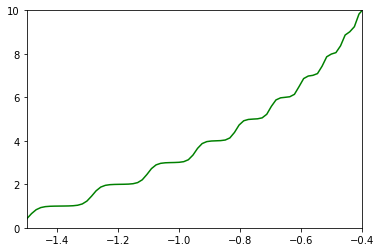

In [34]:
plt.plot(Utab, Ttab , "green");
plt.xlim(-1.5, -0.4)
plt.ylim(0, 10)

In [37]:
# Conductunce in quantum light is also quanthised
def plot_wf(i = 0):
    ene = -1.7 + i / 100
    print("index:", i)
    print("energy:", ene)
    
    wfs = kwant.solvers.default.wave_function(sysf, energy = E_f, params = dict(U = ene))
    scattering_wf = wfs(0) # All scattering wave functions from lead 0
    kwant.plotter.map(sysf, np.sum(abs(scattering_wf)**2, axis = 0));
    
widgets.interact(plot_wf, i = (0,100))


interactive(children=(IntSlider(value=0, description='i'), Output()), _dom_classes=('widget-interact',))

<function __main__.plot_wf(i=0)>